# Confidence-Aware Scoring Supplemental

This is the scoring with vanilla (prompted) GPT models.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import pandas as pd
from tqdm.auto import tqdm

from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
import numpy as np

tqdm.pandas()

data_dir = Path('../../data')

In [65]:
# load original English uses data
datasets = {}
for split in ['test', 'train']:
    datasets[split] = pd.read_json(data_dir/ 'ocsai1'/ f'finetune-gt_main2_prepared_{split}.jsonl', lines=True)
    def parse_prompt(p):
        parts = p.split('\n')
        prompt = parts[0].split(':', 1)[1]
        response = parts[1].split(':', 1)[1]
        return pd.Series({'prompt': prompt, 'response': response})
    datasets[split][['item', 'response']] = datasets[split]['prompt'].apply(parse_prompt)
    datasets[split]['target'] = pd.to_numeric(datasets[split]['completion']).div(10)
    datasets[split]['type'] = 'uses'
    datasets[split].item.value_counts()

data = datasets['test']

# Score

## Score Ocsai 1 Uses, with Plain (Prompted) GPT-4o

In [152]:
# Create a basic few shot prompt by sorting, taking every nth example, then randomizing
fewshot_sample = datasets['train'].sort_values('completion', ascending=False).iloc[::150].sample(frac=1, random_state=42)
display(fewshot_sample.iloc[0])
print("# examples:", len(fewshot_sample))

import tiktoken
encoding = tiktoken.encoding_for_model('gpt-4o')
example_str = ''
for row in fewshot_sample.prompt.str.strip() + fewshot_sample.completion.astype(str):
    example_str += f"\n{row}\n"

print("# tokens:", len(encoding.encode(example_str)))
print('\n```' + example_str[:140] + '...\n```')


prompt        AUT Prompt:hat\nResponse:put it backwards on y...
completion                                                   16
item                                                        hat
response                         put it backwards on your head.
target                                                      1.6
type                                                       uses
Name: 9528, dtype: object

# examples: 108
# tokens: 1924

```
AUT Prompt:hat
Response:put it backwards on your head.
Score:16

AUT Prompt:fork
Response:pick my nose
Score:35

AUT Prompt:ball
Response:c...
```


In [153]:
from ocsai.prompter.ocsai1_chat_prompter import Ocsai1_Chat_Prompter
from ocsai.types import FullScore, ResponseTypes
import textwrap

class GPT_Vanilla_Prompter(Ocsai1_Chat_Prompter):
    sys_msg_text = textwrap.dedent('''
    You score originality in the alternate uses task.

    On a scale of 10-50, judge how original each use is, for the give item, where 10 is 'not at all creative' and 50 is 'very creative'
                                   
    Respond with *JUST* a single number, no other text, just one token score.
                                   
    Here are examples of the task:
    ''' + '\n' + example_str)

    def craft_prompt(self, item, response, task_type='uses', question=None, language='eng'):
        ''' Remove "\nScore:\n" from the legacy format.'''
        prompt = super().craft_prompt(item, response, task_type, question, language)
        return prompt + '\nScore:'

In [154]:
from ocsai.inference import Chat_Scorer
chatscorer = Chat_Scorer(prompter=GPT_Vanilla_Prompter(),
                             model_dict={'gpt-4o':'gpt-4o-2024-08-06',
                                         'gpt-4o-mini':'gpt-4o-mini-2024-07-18'
                                         }) # o3-mini doesn't allow requesting logprobs; a way to get around this is to generate the '<think>' response, then use 4o to score

In [ ]:
def score_weighted(row, model='gpt-4o', top_probs=5, scorer=chatscorer):
    cols = dict()
    try:
        scores = scorer.score(row['item'],
                            response=row['response'], 
                            task_type=row['type'],
                            model=model,
                            top_probs=top_probs,
                            progressive_weighted=True)
        scores = sorted(scores, key=lambda x: x['n'])
        
        for s in scores:
            cols[f'score_{s["n"]}'] = s['score']
            cols[f'confidence_{s["n"]}'] = s['confidence']
    except KeyboardInterrupt:
        raise
    except:
        print(f"Problem with {row['prompt']}")
        for s in range(1, top_probs+1):
            cols[f'score_{s}'] = None
            cols[f'confidence_{s}'] = None
        raise
    return pd.Series(cols)

print(data.iloc[0])
score_weighted(data.iloc[0], top_probs=20)

In [159]:
test = data.sample(100, random_state=42)
top_probs = 20
model = 'gpt-4o'
scorer = chatscorer

responses = test.progress_apply(lambda row: score_weighted(row, model=model, top_probs=top_probs, scorer=scorer), axis=1)
test[responses.columns] = responses.values
test

  0%|          | 0/100 [00:00<?, ?it/s]

,prompt,completion,item,response,target,type,confidence_1,confidence_10,confidence_11,confidence_12,...,score_19,score_2,score_20,score_3,score_4,score_5,score_6,score_7,score_8,score_9
1207,"AUT Prompt:knife\nResponse:If serrated edge, d...",40,knife,"If serrated edge, dots at an equal distance co...",4.0,uses,0.098470,0.652108,0.693157,0.734205,...,3.224155,3.340637,3.209143,3.182425,3.231682,3.176451,3.156194,3.150408,3.211055,3.248274
256,AUT Prompt:book\nResponse:use it to fill other...,37,book,use it to fill otherwise empty space in a box ...,3.7,uses,0.124379,0.804330,0.844710,0.880345,...,2.293808,2.243782,2.298013,2.120102,2.202902,2.238173,2.217200,2.286045,2.315685,2.283716
2356,AUT Prompt:bottle\nResponse:chill fluids in\nS...,15,bottle,chill fluids in,1.5,uses,0.172320,0.902631,0.925952,0.949273,...,1.688806,1.631347,1.689774,1.725086,1.720489,1.648027,1.609946,1.635488,1.632616,1.615199
175,AUT Prompt:paperclip\nResponse:stick between t...,23,paperclip,stick between two items,2.3,uses,0.184597,0.910691,0.932738,0.954785,...,1.625307,1.631347,1.625761,1.531573,1.509268,1.482035,1.507134,1.552599,1.581938,1.583191
211,AUT Prompt:bottle\nResponse:windchimes\nScore:\n,43,bottle,windchimes,4.3,uses,0.146849,0.845754,0.878521,0.911287,...,3.488744,3.659363,3.485715,3.641991,3.587207,3.605989,3.559382,3.503849,3.479737,3.503498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
527,AUT Prompt:table\nResponse:as a ladder to reac...,30,table,as a ladder to reach high places,3.0,uses,0.076489,0.650075,0.696468,0.742861,...,2.317570,2.000000,2.304964,2.266667,2.206053,2.260493,2.266667,2.282825,2.263064,2.301113
139,AUT Prompt:brick\nResponse:eat it\nScore:\n,22,brick,eat it,2.2,uses,0.102844,0.717565,0.750953,0.780419,...,4.000440,4.531209,3.985529,4.202081,4.274161,4.190733,4.084455,4.086103,4.094791,4.038355
2816,AUT Prompt:rope\nResponse:tripping people\nSco...,13,rope,tripping people,1.3,uses,0.138498,0.856126,0.895807,0.926710,...,1.830632,1.893758,1.833617,1.895585,1.806029,1.871632,1.843737,1.867603,1.854875,1.826303
1867,AUT Prompt:sock\nResponse:A popsicle holder.\n...,36,sock,A popsicle holder.,3.6,uses,0.164698,0.827771,0.860202,0.888822,...,3.453312,3.540733,3.458151,3.615775,3.632911,3.593535,3.556934,3.492527,3.465314,3.435716


In [177]:
#test = data.sample(100)
top_probs = 20
model = 'gpt-4o'
scorer = chatscorer
responses = data.progress_apply(lambda row: score_weighted(row, model=model, top_probs=top_probs, scorer=scorer), axis=1)
data[responses.columns] = responses.values

  0%|          | 0/3030 [00:00<?, ?it/s]

In [179]:
for i in range(1, 20):
    # get correlation between score_i and target
    ignore = data[f'score_{i}'].isna()
    if ignore.sum() > 0:
        print(f'Score {i} has {ignore.sum()} missing values')
    
    # Calculate both correlation and RMSE for non-missing values
    valid_data = data[~ignore]
    r = pearsonr(valid_data[f'score_{i}'], valid_data['target'])[0]
    rmse = np.sqrt(mean_squared_error(valid_data['target'], valid_data[f'score_{i}']))
    print(f'Score {i} - correlation: {r:.3f}, RMSE: {rmse:.4f}')

Score 1 - correlation: 0.607, RMSE: 0.7656
Score 2 - correlation: 0.618, RMSE: 0.7497
Score 3 - correlation: 0.620, RMSE: 0.7435
Score 4 - correlation: 0.622, RMSE: 0.7393
Score 5 - correlation: 0.622, RMSE: 0.7376
Score 6 - correlation: 0.623, RMSE: 0.7348
Score 7 - correlation: 0.624, RMSE: 0.7326
Score 8 - correlation: 0.624, RMSE: 0.7313
Score 9 - correlation: 0.625, RMSE: 0.7302
Score 10 - correlation: 0.625, RMSE: 0.7287
Score 11 - correlation: 0.626, RMSE: 0.7283
Score 12 - correlation: 0.626, RMSE: 0.7267
Score 13 - correlation: 0.627, RMSE: 0.7259
Score 14 - correlation: 0.627, RMSE: 0.7256
Score 15 - correlation: 0.627, RMSE: 0.7253
Score 16 has 6 missing values
Score 16 - correlation: 0.625, RMSE: 0.7255
Score 17 has 13 missing values
Score 17 - correlation: 0.624, RMSE: 0.7263
Score 18 has 27 missing values
Score 18 - correlation: 0.620, RMSE: 0.7275
Score 19 has 55 missing values
Score 19 - correlation: 0.614, RMSE: 0.7297


In [180]:
data.to_csv(data_dir / 'results' / f'logprobs_{model}_ocsai1.csv', index=False)

### Example Probs, for paper

np.exp(log_prob)

In [248]:
example1 = data.loc[1989].copy()
example1['score_10'] = np.round(example1['score_10'], 1)
example1[['item', 'response', 'target', 'score_1', 'score_10']]

item            paperclip
response    remove grout 
target                2.5
score_1               2.2
score_10              2.5
Name: 1989, dtype: object

In [262]:
#score_weighted(example1, top_probs=10) # ugly - I printed the probs_to_parse[-1] inside the base_scorer and copied here
logprobs = [('22', -1.85019), ('26', -1.85019), ('28', -2.2251902), ('24', -2.3501902), ('29', -2.7251902), ('23', -2.7251902), ('27', -2.8501902), ('20', -2.9751902), ('21', -2.9751902), ('25', -3.1001902)]
for score, logprob in logprobs:
    print("token:", int(score)/10, "prob:", (np.exp(logprob) * 100).round(2))

token: 2.2 prob: 15.72
token: 2.6 prob: 15.72
token: 2.8 prob: 10.8
token: 2.4 prob: 9.54
token: 2.9 prob: 6.55
token: 2.3 prob: 6.55
token: 2.7 prob: 5.78
token: 2.0 prob: 5.1
token: 2.1 prob: 5.1
token: 2.5 prob: 4.5


# Analysis

## Prep Data

In [181]:
collector = []
id_vars = ['run','type', 'item', 'response', 'target']

for model in ['ocsai-babbage2', 'ocsai-davinci2', 'ocsai-chatgpt', 'gpt-4o-mini', 'gpt-4o']:
    df = pd.read_csv(data_dir / 'results' / f'logprobs_{model}_ocsai1.csv')
    df['run'] = model

    # when an item doesn't have a score for the n*th contributor
    # (e.g. looking at top_logprobs=5 but only 4 are provided), 
    # use the previous slots score.

    max_contributors = max([int(c.split('_')[1]) for c in df.columns if c.startswith('score')])
    for i in range(1, max_contributors+1):
        if (i - 1) <= 0:
            continue
        for cat in ['score', 'confidence']:
            prev, col = f'{cat}_{i-1}', f'{cat}_{i}'
            df.loc[df[col].isna(), col] = df.loc[df[col].isna(), prev]

    collector.append(df)
df = pd.concat(collector)

scores_long = df.melt(id_vars=id_vars,
        value_vars=[c for c in df.columns if c.startswith('score_')],
        var_name='contributors',
        value_name='score')

confidences_long = df.melt(id_vars=id_vars,
        value_vars=[c for c in df.columns if c.startswith('confidence_')],
        var_name='contributors',
        value_name='confidence')

scores_long.contributors = scores_long.contributors.str.extract(r'(\d+)').astype(int)
confidences_long.contributors = confidences_long.contributors.str.extract(r'(\d+)').astype(int)

long = scores_long.merge(confidences_long, on=id_vars + ['contributors']).dropna()
# for fairness, keep same precision
long['score'] = long['score'].round(1)

display(long.dropna()['run'].value_counts())
long.sample(5)

run
ocsai-chatgpt     60600
gpt-4o-mini       60600
gpt-4o            60600
ocsai-babbage2    15150
ocsai-davinci2    15150
Name: count, dtype: int64

,run,type,item,response,target,contributors,score,confidence
30006,gpt-4o,uses,knife,to cut wood,1.3,2,1.3,0.406496
63805,ocsai-davinci2,uses,paperclip,stick between two items,2.3,5,1.9,0.660842
188685,ocsai-chatgpt,uses,knife,pry bar,1.3,17,1.9,0.990036
151410,gpt-4o,uses,knife,tooth flosser,2.3,14,1.6,0.927384
190950,gpt-4o-mini,uses,paperclip,Connector,2.3,17,1.3,1.000000


In [182]:
# calculate RMSE and Pearson r for target vs score, by group
def evaluate(x):
    r = pearsonr(x['target'], x['score'])[0] # the second item is p-value, which at this scale doesn't need reporting (since it's only not significant when r is very, very low)
    rmse = np.sqrt(mean_squared_error(x['target'], x['score']))
    n = len(x)
    return pd.Series({'r': np.round(r, 3), 'RMSE':np.round(rmse,4), 'n': n})

## Weighted Measure Eval

In [184]:
evaluated = long.dropna().groupby(['run', 'contributors'])[['target', 'score']].apply(evaluate)
display(evaluated.iloc[:35])
display(evaluated.iloc[35:])

r    RMSE       n
run         contributors                       
gpt-4o      1             0.607  0.7656  3030.0
            2             0.618  0.7497  3030.0
            3             0.620  0.7451  3030.0
            4             0.621  0.7404  3030.0
            5             0.622  0.7381  3030.0
            6             0.623  0.7360  3030.0
            7             0.623  0.7330  3030.0
            8             0.624  0.7319  3030.0
            9             0.625  0.7308  3030.0
            10            0.626  0.7288  3030.0
            11            0.626  0.7283  3030.0
            12            0.625  0.7281  3030.0
            13            0.626  0.7269  3030.0
            14            0.627  0.7257  3030.0
            15            0.626  0.7264  3030.0
            16            0.626  0.7259  3030.0
            17            0.626  0.7260  3030.0
            18            0.627  0.7253  3030.0
            19            0.627  0.7246  3030.0
            20            0.627  0.7240  3030.0
gpt-4o-mini 1             0.508  0.9895  3030.0
            2             0.514  0.9755  3030.0
            3             0.518  0.9681  3030.0
            4             0.520  0.9648  3030.0
            5             0.520  0.9643  3030.0
            6             0.521  0.9629  3030.0
            7             0.521  0.9623  3030.0
            8             0.522  0.9615  3030.0
            9             0.521  0.9613  3030.0
            10            0.522  0.9603  3030.0
            11            0.522  0.9601  3030.0
            12            0.523  0.9596  3030.0
            13            0.523  0.9592  3030.0
            14            0.523  0.9591  3030.0
            15            0.523  0.9591  3030.0

r    RMSE       n
run            contributors                       
gpt-4o-mini    16            0.523  0.9589  3030.0
               17            0.523  0.9588  3030.0
               18            0.523  0.9587  3030.0
               19            0.523  0.9586  3030.0
               20            0.523  0.9586  3030.0
ocsai-babbage2 1             0.722  0.6614  3030.0
               2             0.736  0.6345  3030.0
               3             0.741  0.6218  3030.0
               4             0.747  0.6099  3030.0
               5             0.749  0.6042  3030.0
ocsai-chatgpt  1             0.781  0.5990  3030.0
               2             0.801  0.5571  3030.0
               3             0.809  0.5388  3030.0
               4             0.813  0.5301  3030.0
               5             0.816  0.5235  3030.0
               6             0.817  0.5198  3030.0
               7             0.818  0.5160  3030.0
               8             0.818  0.5148  3030.0
               9             0.819  0.5117  3030.0
               10            0.819  0.5103  3030.0
               11            0.819  0.5096  3030.0
               12            0.821  0.5067  3030.0
               13            0.821  0.5058  3030.0
               14            0.820  0.5056  3030.0
               15            0.820  0.5054  3030.0
               16            0.820  0.5051  3030.0
               17            0.820  0.5040  3030.0
               18            0.821  0.5037  3030.0
               19            0.820  0.5038  3030.0
               20            0.820  0.5038  3030.0
ocsai-davinci2 1             0.774  0.5653  3030.0
               2             0.788  0.5421  3030.0
               3             0.794  0.5310  3030.0
               4             0.798  0.5238  3030.0
               5             0.799  0.5210  3030.0

In [185]:
# Formatted for Paper
x = evaluated.melt(ignore_index=False, value_vars=['r', 'RMSE'], var_name='metric', value_name='value').reset_index()
x = x.query('contributors <= 5')
x.pivot(index=['contributors'], columns=['run', 'metric'], values=['value'])

value                                                          \
run          gpt-4o gpt-4o-mini ocsai-babbage2 ocsai-chatgpt ocsai-davinci2   
metric            r           r              r             r              r   
contributors                                                                  
1             0.607       0.508          0.722         0.781          0.774   
2             0.618       0.514          0.736         0.801          0.788   
3             0.620       0.518          0.741         0.809          0.794   
4             0.621       0.520          0.747         0.813          0.798   
5             0.622       0.520          0.749         0.816          0.799   

                                                                              
run           gpt-4o gpt-4o-mini ocsai-babbage2 ocsai-chatgpt ocsai-davinci2  
metric          RMSE        RMSE           RMSE          RMSE           RMSE  
contributors                                                                  
1             0.7656      0.9895         0.6614        0.5990         0.5653  
2             0.7497      0.9755         0.6345        0.5571         0.5421  
3             0.7451      0.9681         0.6218        0.5388         0.5310  
4             0.7404      0.9648         0.6099        0.5301         0.5238  
5             0.7381      0.9643         0.6042        0.5235         0.5210

Measure stability

It looks near-monotonic:

<Axes: xlabel='contributors'>

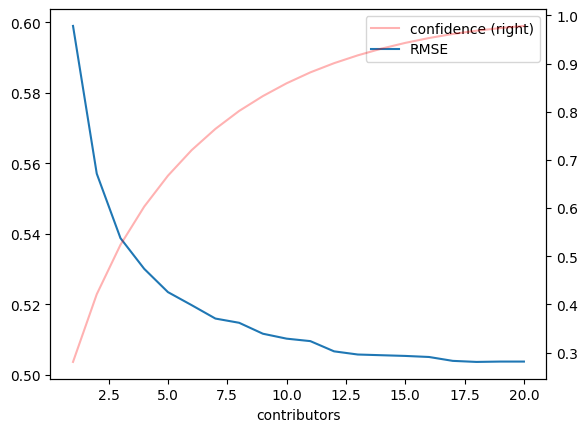

In [176]:
avg_conf = long[long.run == 'ocsai-chatgpt'].groupby('contributors', as_index=False)[['confidence']].mean()
avg_conf.contributors = avg_conf.contributors.astype(int)
ax = avg_conf.plot(x='contributors', y='confidence', secondary_y=True, color='red', alpha=.3, style='-')

evaluated.loc['ocsai-chatgpt'].reset_index().plot(x='contributors', y='RMSE', ax=ax)

## Confidence Eval

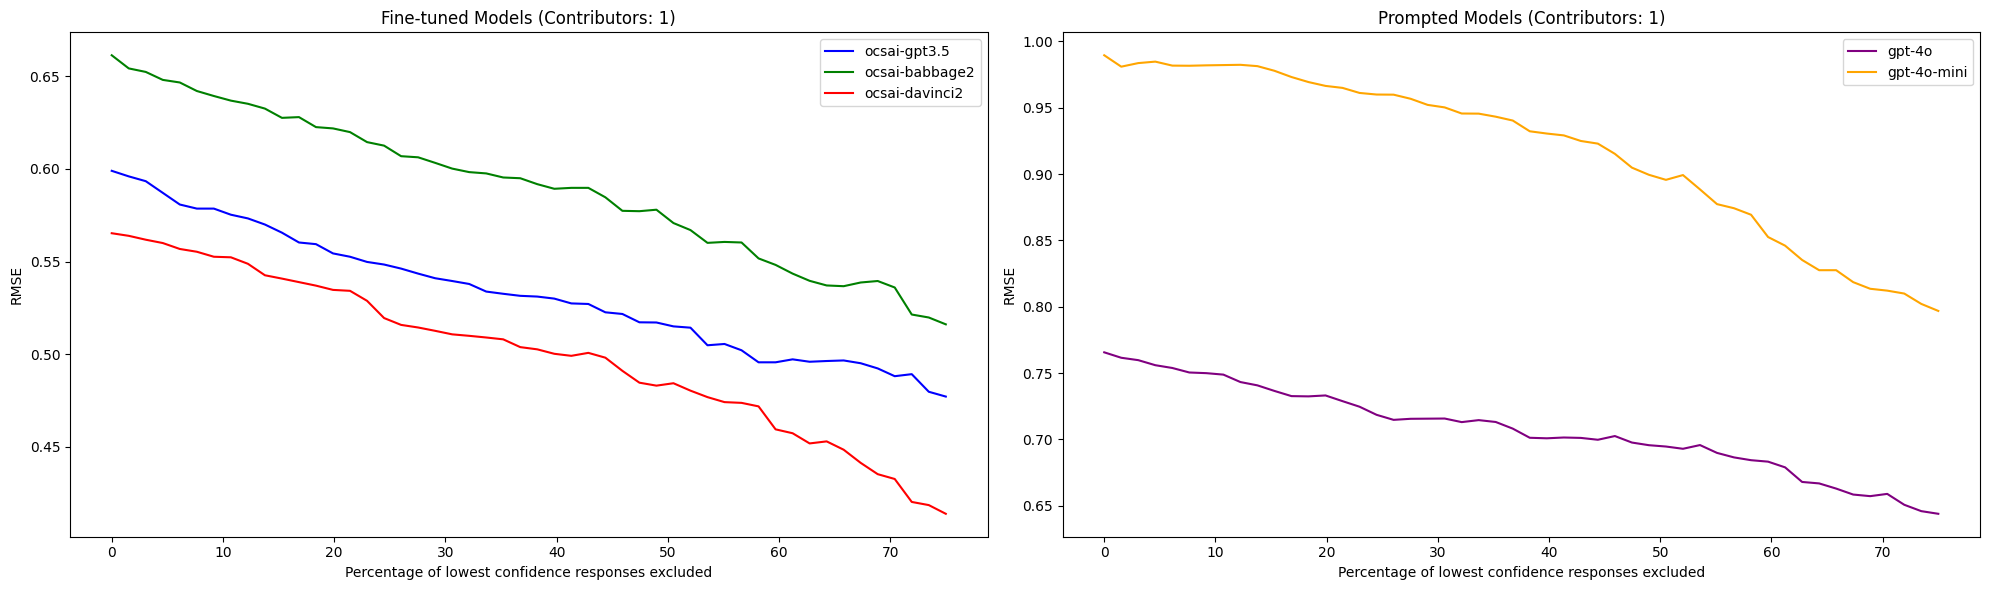

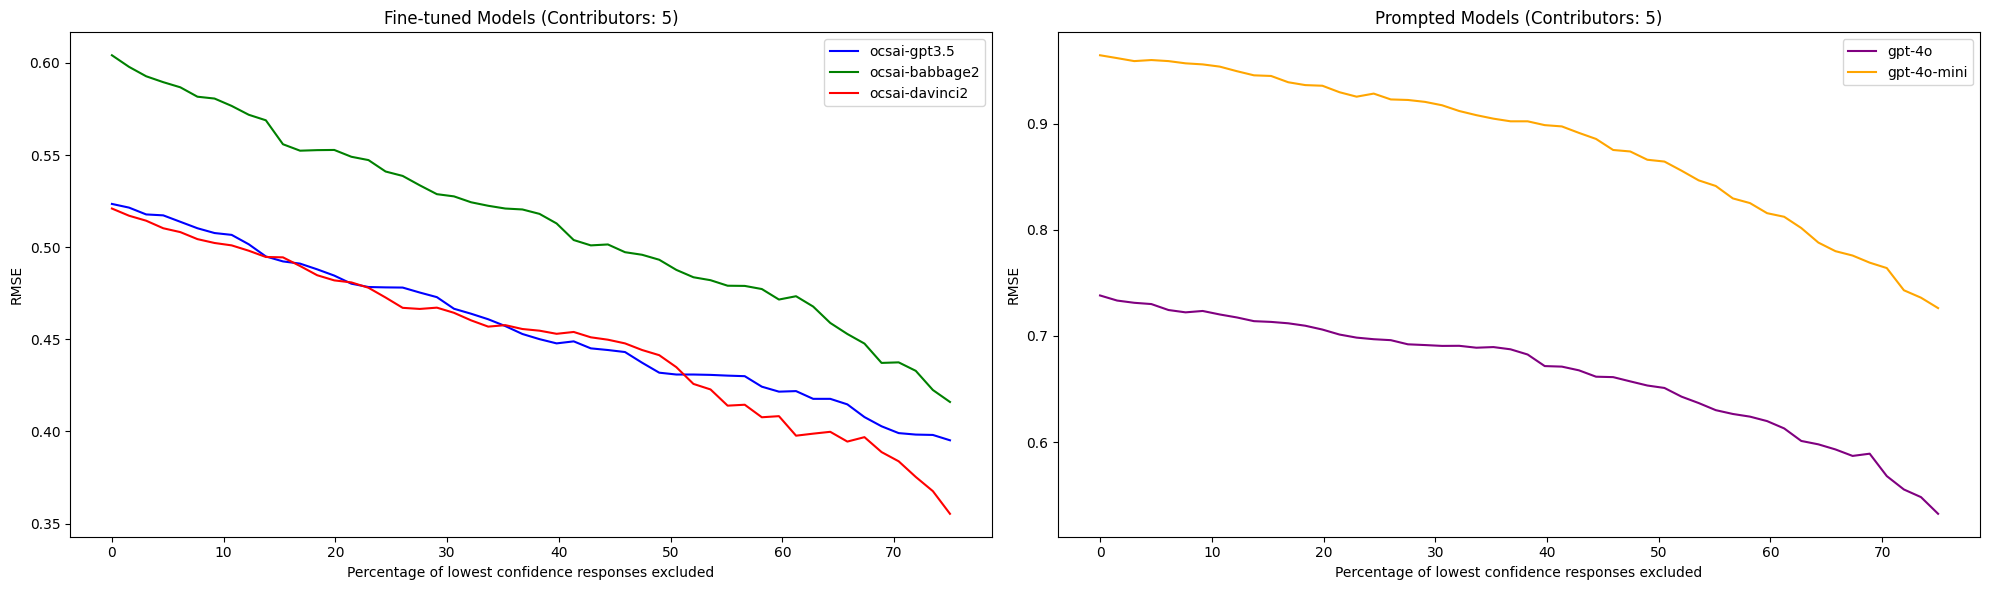

In [268]:
# Plot confidence threshold analysis for all models
n_bins = 10
top_probs = 5

# Split models into two groups
traditional_models = ['ocsai-gpt3.5', 'ocsai-babbage2', 'ocsai-davinci2']  # renamed from ocsai-chatgpt
gpt4_models = ['gpt-4o', 'gpt-4o-mini']

model_groups = {
    'Fine-tuned Models': {'models': traditional_models, 'colors': ['blue', 'green', 'red']},
    'Prompted Models': {'models': gpt4_models, 'colors': ['purple', 'orange']}
}

# For each contributor count
for i in [1, 5]:
    # Create a single figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
    
    # Plot each group in its respective subplot
    for (group_name, group_info), ax in zip(model_groups.items(), [ax1, ax2]):
        # For each model in the group
        for model, color in zip(group_info['models'], group_info['colors']):
            # Handle the model name replacement in the data
            data_model = 'ocsai-chatgpt' if model == 'ocsai-gpt3.5' else model
            subset = long[(long.contributors == i) & (long['run'] == data_model)].dropna().copy()
            
            # Calculate threshold performance
            rows = []
            percentiles = np.linspace(0, 75, 50)
            
            for percentile in percentiles:
                threshold = subset['confidence'].quantile(percentile/100)
                filtered_subset = subset[subset['confidence'] >= threshold]
                if len(filtered_subset) <= 100:
                    continue
                row = evaluate(filtered_subset)
                row['percentile_dropped'] = percentile
                rows.append(row)
                
            df = pd.DataFrame(rows)
            # Use the display model name (with ocsai-gpt3.5) instead of the data model name
            df.plot(x='percentile_dropped', y='RMSE', color=color, label=model, ax=ax)
        
        ax.set_xlabel("Percentage of lowest confidence responses excluded")
        ax.set_ylabel("RMSE")
        ax.legend()
        ax.set_title(f"{group_name} (Contributors: {i})")
    
    plt.tight_layout()
    plt.show()

What's a reasonable number? Maybe one-fifth? If we commit to dropping the bottom fifth of auto-scored responses what is the performance (in RMSE and r, by model)?

In [270]:
# Calculate baseline and filtered metrics for comparison
results = []
for model in ['ocsai-chatgpt', 'ocsai-babbage2', 'ocsai-davinci2', 'gpt-4o', 'gpt-4o-mini']:
    for i in range(1, 6):  # Looking at first 5 contributors
        subset = long[(long.contributors == i) & (long['run'] == model)].dropna().copy()
        
        # Baseline metrics (all data)
        baseline_metrics = evaluate(subset)
        baseline_metrics['model'] = model
        baseline_metrics['contributors'] = i
        baseline_metrics['filtered'] = False
        results.append(baseline_metrics)
        
        # Filtered metrics (top 80%)
        threshold = subset['confidence'].quantile(0.2)
        filtered = subset[subset['confidence'] >= threshold]
        filtered_metrics = evaluate(filtered)
        filtered_metrics['model'] = model
        filtered_metrics['contributors'] = i
        filtered_metrics['filtered'] = True
        results.append(filtered_metrics)

results = pd.DataFrame(results)

print("Single contributor performance (baseline vs dropping bottom 20%):")
display(results.query('contributors == 1')
        .drop(columns=['contributors'])
        .set_index(['model', 'filtered'])
        .sort_index())

print("\nFive contributor performance (baseline vs dropping bottom 20%):")
display(results.query('contributors == 5')
        .drop(columns=['contributors'])
        .set_index(['model', 'filtered'])
        .sort_index())

Single contributor performance (baseline vs dropping bottom 20%):


r    RMSE       n
model          filtered                       
gpt-4o         False     0.607  0.7656  3030.0
               True      0.656  0.7329  2424.0
gpt-4o-mini    False     0.508  0.9895  3030.0
               True      0.533  0.9666  2424.0
ocsai-babbage2 False     0.722  0.6614  3030.0
               True      0.765  0.6206  2424.0
ocsai-chatgpt  False     0.781  0.5990  3030.0
               True      0.822  0.5544  2424.0
ocsai-davinci2 False     0.774  0.5653  3030.0
               True      0.809  0.5348  2424.0


Five contributor performance (baseline vs dropping bottom 20%):


r    RMSE       n
model          filtered                       
gpt-4o         False     0.622  0.7381  3030.0
               True      0.673  0.7062  2424.0
gpt-4o-mini    False     0.520  0.9643  3030.0
               True      0.545  0.9358  2424.0
ocsai-babbage2 False     0.749  0.6042  3030.0
               True      0.795  0.5531  2424.0
ocsai-chatgpt  False     0.816  0.5235  3030.0
               True      0.846  0.4848  2424.0
ocsai-davinci2 False     0.799  0.5210  3030.0
               True      0.838  0.4821  2424.0

Score 1 correlation with confidence bins


,r,RMSE,n
confidence,,,
"(0.0738, 0.129]",0.480,0.7672,303.0
"(0.129, 0.148]",0.609,0.7353,303.0
"(0.148, 0.167]",0.719,0.6474,303.0
"(0.167, 0.188]",0.776,0.5922,303.0
"(0.188, 0.212]",0.759,0.5991,303.0
"(0.212, 0.244]",0.761,0.5913,303.0
"(0.244, 0.287]",0.814,0.5095,303.0
"(0.287, 0.36]",0.786,0.5574,303.0
"(0.36, 0.558]",0.834,0.5447,303.0


Score 2 correlation with confidence bins


,r,RMSE,n
confidence,,,
"(0.145, 0.231]",0.518,0.7011,303.0
"(0.231, 0.266]",0.653,0.6951,303.0
"(0.266, 0.297]",0.729,0.6043,303.0
"(0.297, 0.327]",0.789,0.5692,303.0
"(0.327, 0.363]",0.769,0.5668,303.0
"(0.363, 0.404]",0.798,0.5518,303.0
"(0.404, 0.462]",0.818,0.4853,303.0
"(0.462, 0.547]",0.796,0.5277,303.0
"(0.547, 0.723]",0.856,0.4381,303.0


Score 3 correlation with confidence bins


,r,RMSE,n
confidence,,,
"(0.216, 0.318]",0.582,0.6499,303.0
"(0.318, 0.365]",0.639,0.7154,303.0
"(0.365, 0.404]",0.733,0.5879,303.0
"(0.404, 0.44]",0.795,0.5803,303.0
"(0.44, 0.48]",0.784,0.5273,303.0
"(0.48, 0.524]",0.811,0.5184,303.0
"(0.524, 0.583]",0.824,0.4539,303.0
"(0.583, 0.655]",0.814,0.5074,303.0
"(0.655, 0.841]",0.860,0.4211,303.0


Score 4 correlation with confidence bins


,r,RMSE,n
confidence,,,
"(0.285, 0.397]",0.570,0.6569,303.0
"(0.397, 0.449]",0.621,0.6942,303.0
"(0.449, 0.492]",0.763,0.5834,303.0
"(0.492, 0.532]",0.779,0.5663,303.0
"(0.532, 0.57]",0.807,0.5229,303.0
"(0.57, 0.617]",0.821,0.4851,303.0
"(0.617, 0.672]",0.814,0.4809,303.0
"(0.672, 0.74]",0.817,0.4702,303.0
"(0.74, 0.9]",0.829,0.4291,303.0


Score 5 correlation with confidence bins


,r,RMSE,n
confidence,,,
"(0.352, 0.465]",0.559,0.6528,303.0
"(0.465, 0.521]",0.656,0.6594,303.0
"(0.521, 0.567]",0.784,0.5736,303.0
"(0.567, 0.608]",0.767,0.5888,303.0
"(0.608, 0.649]",0.800,0.5235,303.0
"(0.649, 0.689]",0.813,0.4669,303.0
"(0.689, 0.741]",0.803,0.4865,303.0
"(0.741, 0.807]",0.819,0.4513,303.0
"(0.807, 0.932]",0.802,0.4330,303.0


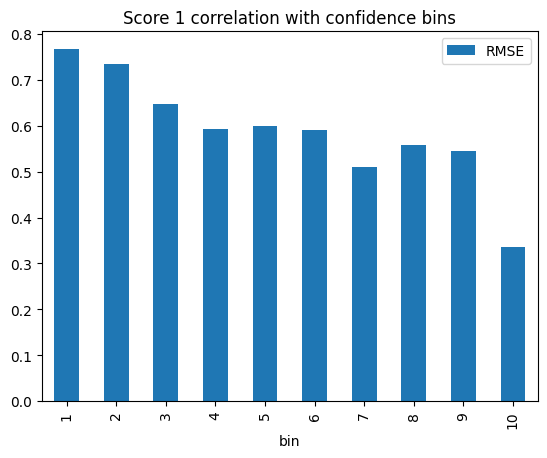

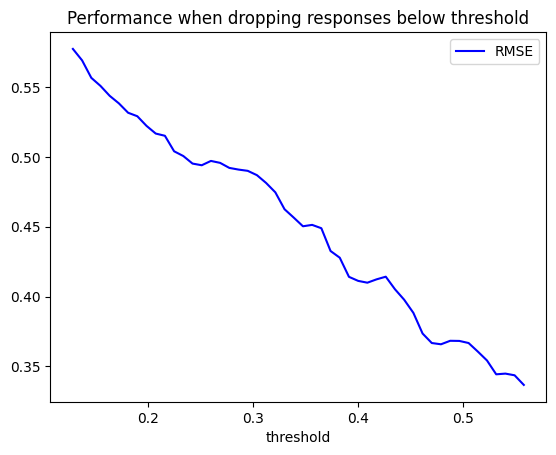

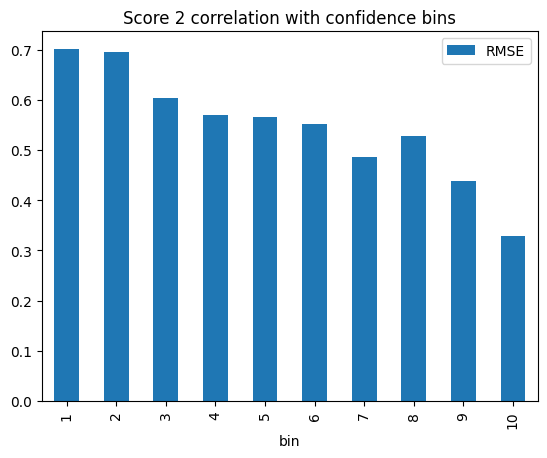

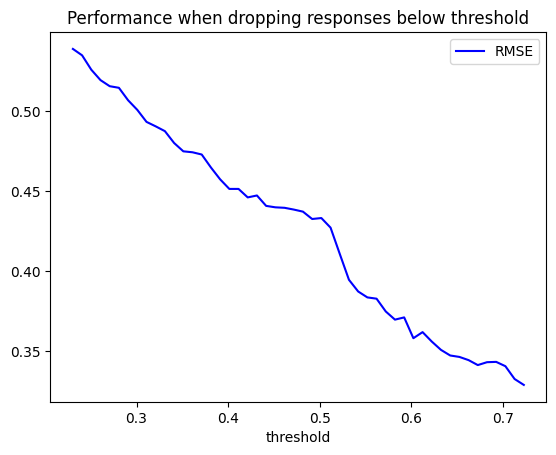

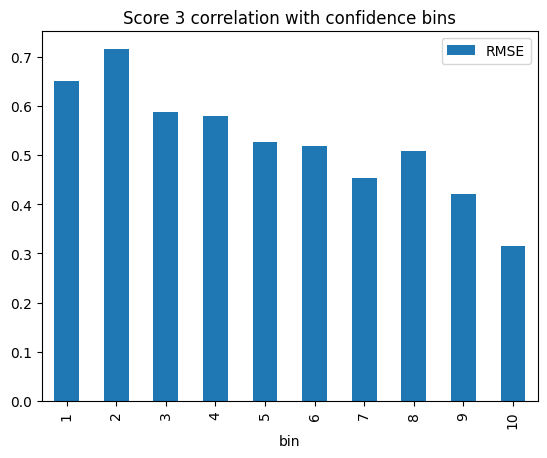

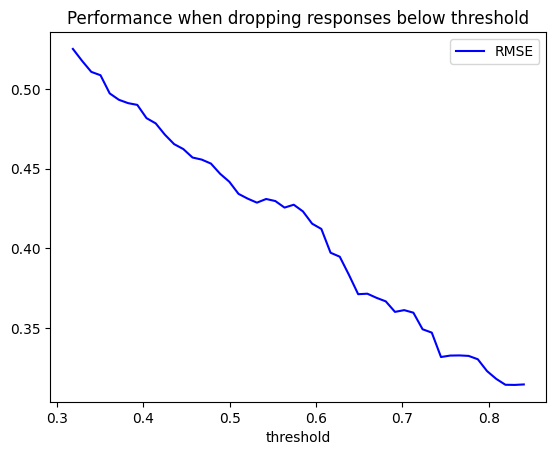

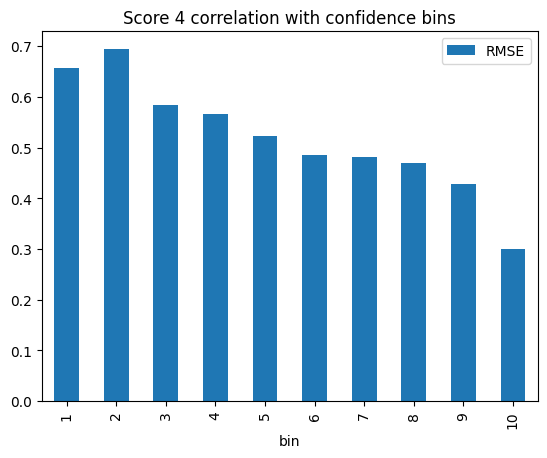

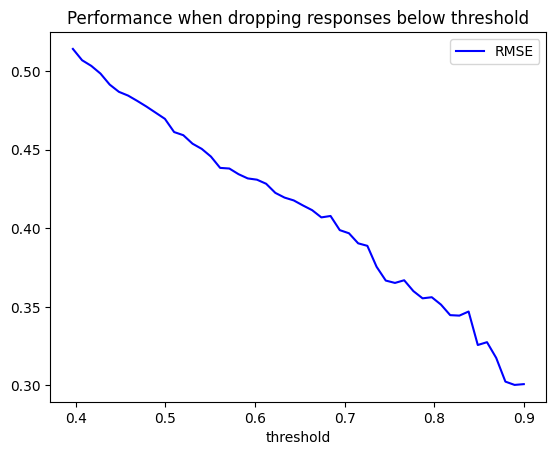

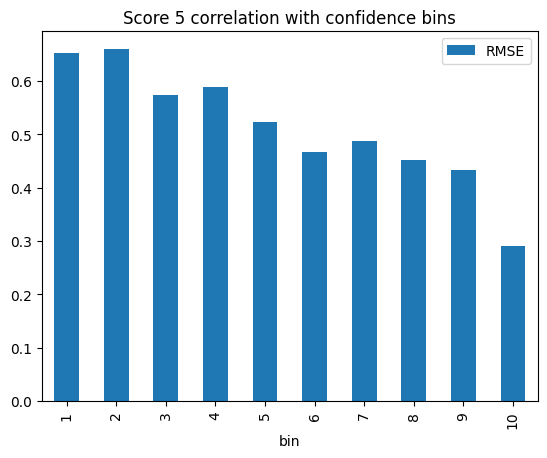

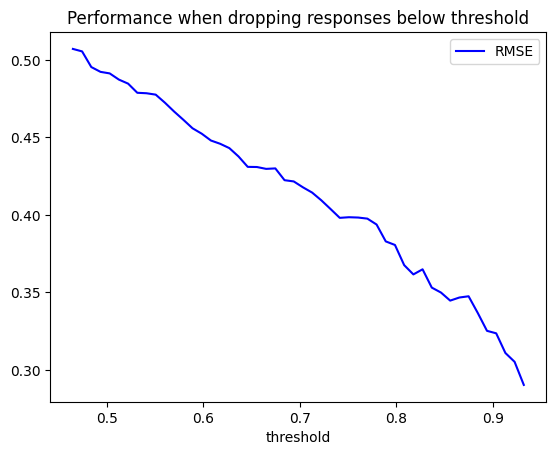

In [77]:
# OLD code - was not good communication.
# split data into x bins based on confidence_1 column, then seen the correlation between score_1 and target at each bin
n_bins = 10
top_probs = 5
model = 'ocsai-chatgpt'
for i in range(1, top_probs+1):
    subset = long[(long.contributors == i) & (long['run'] == model)].dropna().copy()
    print(f"Score {i} correlation with confidence bins")
    confidence_bin = pd.qcut(subset['confidence'], n_bins)
    df = subset.groupby(confidence_bin, observed=False).apply(evaluate)
    display(df)

    # Plot bins
    df['bin'] = range(1, len(df)+1)
    ax = df.plot(x='bin', y='RMSE', kind='bar')
    # second axis is too confusing
    #df.plot(x='bin', y='r', ax=ax, color='red', secondary_y=True)
    ax.set_title(f"Score {i} correlation with confidence bins")

    # consider performance when dropping responses below a threshold
    rows = []
    tenth, ninetieth = subset.confidence.quantile([0.1, 0.9]).tolist()
    thresholds = np.linspace(tenth, ninetieth, 50)
    for threshold in thresholds:
        filtered_subset = subset[subset['confidence'] >= threshold]
        if len(filtered_subset) <= 100:
            row = {'r': None, 'RMSE': None, 'n': len(filtered_subset), 'threshold': threshold}
            continue
        row = evaluate(filtered_subset)
        row['threshold'] = threshold
        rows.append(row)
    df = pd.DataFrame(rows)
    ax = df.plot(x='threshold', y='RMSE', color='blue', kind='line')
    # df.plot(x='threshold', y='n', ax=ax, secondary_y=True, color='red', alpha=0.5, kind='line')
    ax.set_title(f"Performance when dropping responses below threshold")

In [51]:
import statsmodels.api as sm

for_ols = long.dropna().copy()
for_ols['abs_error'] = abs(for_ols['target'] - for_ols['score'])

for_ols = pd.get_dummies(for_ols, columns=['run'], drop_first=True)

X = for_ols[['confidence', 'contributors'] + [col for col in for_ols.columns if col.startswith('run_')]]
X = sm.add_constant(X)
y = for_ols['abs_error']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              abs_error   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     625.6
Date:                Thu, 16 May 2024   Prob (F-statistic):          8.90e-262
Time:                        14:16:16   Log-Likelihood:                -7770.4
No. Observations:               15147   AIC:                         1.555e+04
Df Residuals:                   15144   BIC:                         1.557e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.6145      0.008     72.897   

In [54]:
from statsmodels.robust.robust_linear_model import RLM
rlm_model = RLM(y, X, M=sm.robust.norms.HuberT()).fit()
print(rlm_model.summary())

                    Robust linear Model Regression Results                    
Dep. Variable:              abs_error   No. Observations:                15147
Model:                            RLM   Df Residuals:                    15144
Method:                          IRLS   Df Model:                            2
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Thu, 16 May 2024                                         
Time:                        14:17:53                                         
No. Iterations:                    36                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.5394      0.007     73.904   

## Ensemble Model Eval

In [36]:
from itertools import combinations

ensemble_model_pool = ['ocsai-babbage2', 'ocsai-davinci2', 'ocsai-chatgpt', 'gpt-4o', 'gpt-4o-mini']
ensemble_sizes = [2, 3, 5]  # pairwise + larger ensembles
max_contributors = 5
require_all_models = True

model_labels = {
    'ocsai-babbage2': 'babbage2',
    'ocsai-davinci2': 'davinci2',
    'ocsai-chatgpt': 'chatgpt',
    'gpt-4o': 'gpt4o',
    'gpt-4o-mini': 'gpt4o-mini',
}

def build_ensemble_specs(models, sizes):
    specs = {}
    for size in sizes:
        for combo in combinations(models, size):
            name = '+'.join(model_labels[m] for m in combo)
            specs[name] = list(combo)
    return specs

def build_ensemble(long_df, runs, max_contributors=5, require_all=True):
    group_cols = ['item', 'response', 'target', 'type', 'contributors']
    subset = long_df[(long_df.contributors <= max_contributors) & long_df.run.isin(runs)].copy()
    if require_all:
        counts = subset.groupby(group_cols)['run'].nunique()
        complete_keys = counts[counts == len(runs)].index
        subset = subset.set_index(group_cols).loc[complete_keys].reset_index()
    return subset.groupby(group_cols, as_index=False)[['score', 'confidence']].mean()

ensemble_specs = build_ensemble_specs(ensemble_model_pool, ensemble_sizes)

ensemble_results = []
for name, runs in ensemble_specs.items():
    ensemble_df = build_ensemble(long, runs, max_contributors=max_contributors, require_all=require_all_models)
    if ensemble_df.empty:
        continue
    metrics = ensemble_df.groupby('contributors').apply(evaluate).reset_index()
    metrics['ensemble'] = name
    metrics['models'] = ','.join(runs)
    ensemble_results.append(metrics)

ensemble_results = pd.concat(ensemble_results, ignore_index=True)
display(ensemble_results.sort_values(['contributors', 'RMSE']))


,r,RMSE,n
contributors,,,
1,0.805,0.5378,3030.0
2,0.815,0.5175,3030.0
3,0.820,0.5068,3030.0
4,0.822,0.5013,3030.0
5,0.823,0.4978,3030.0


In [ ]:
# Chart ensemble composition as stacked bars
contributors = 1
sort_by = 'r'  # 'r' (desc) or 'RMSE' (asc)

subset = ensemble_results[ensemble_results['contributors'] == contributors].copy()
subset['model_list'] = subset['models'].str.split(',')

if sort_by == 'r':
    subset = subset.sort_values('r', ascending=False)
elif sort_by == 'RMSE':
    subset = subset.sort_values('RMSE', ascending=True)

model_order = [
    'ocsai-babbage2',
    'ocsai-davinci2',
    'ocsai-chatgpt',
    'gpt-4o',
    'gpt-4o-mini',
]
model_colors = {
    'ocsai-babbage2': '#8c8c8c',
    'ocsai-davinci2': '#4c72b0',
    'ocsai-chatgpt': '#55a868',
    'gpt-4o': '#c44e52',
    'gpt-4o-mini': '#8172b3',
}

fig_height = max(2.5, len(subset) * 0.45)
fig, ax = plt.subplots(figsize=(9, fig_height))

for idx, row in subset.reset_index(drop=True).iterrows():
    left = 0
    for model in row['model_list']:
        ax.barh(idx, 1, left=left, color=model_colors.get(model, '#333333'), edgecolor='white', height=0.7)
        left += 1
    metric_label = f"r={row['r']:.3f}, RMSE={row['RMSE']:.4f}"
    ax.text(left + 0.1, idx, metric_label, va='center', fontsize=9)

ax.set_yticks(range(len(subset)))
ax.set_yticklabels(subset['ensemble'])
ax.set_xlim(0, subset['model_list'].str.len().max() + 2)
ax.set_xlabel('Ensemble composition (equal-width model segments)')
ax.set_title(f'LLM Ensemble Composition (contributors={contributors})')

handles = [plt.Line2D([0], [0], color=model_colors[m], lw=6) for m in model_order]
labels = model_order
ax.legend(handles, labels, title='Models', loc='lower right')

plt.tight_layout()
plt.show()
